# 04 — Feature Analysis (3-Stage Band Selection)

A novel 3-stage pipeline to select the optimal spectral–temporal band subset for semantic segmentation.

| Stage | Method | Cost | Output |
|---|---|---|---|
| 1 — Filter | GSI + RF importance → joint score | Very low | Top ~25 candidate channels |
| 2 — CNN Forward Selection | Lightweight U-Net as wrapper oracle | Medium | ~10–15 selected channels |
| 3 — Full Validation | U-Net / DeepLabV3+ / SegFormer | High | mIoU comparison table |

**Assumes `02_image_processing` has been run.** Preprocessed chips (images + masks) must exist in `data/processed/`.

## Configuration

In [8]:
import sys, os, re
from glob import glob
sys.path.append("../")

# ── Data paths (outputs of 02_image_processing.ipynb) ────────────────────────
PROCESSED_DIR    = "/Volumes/T7/research-crop-mapping-geoai/data/processed"
S2_PROCESSED_DIR = os.path.join(PROCESSED_DIR, "s2")
CDL_FILTERED     = os.path.join(PROCESSED_DIR, "cdl", "cdl_2022_study_area_filtered.tif")  # 2022 CDL only
FIGURES_DIR      = "../documents/thesis/figures"   # saved directly to thesis figure directory
os.makedirs(FIGURES_DIR, exist_ok=True)

# Feature analysis uses 2022 ONLY — selected K* bands are year-agnostic
# (spectral separability is physically determined by crop signatures, not year).
# The same K* bands will be applied to 2022+2023 training and 2024 testing.
S2_PROCESSED     = sorted([
    p for p in glob(f"{S2_PROCESSED_DIR}/*_processed.tif")
    if os.path.basename(p).split("_")[1] == "2022"
])

# S2 band names — GEE export order (11 bands: B1,B2..B7,B8,B8A,B11,B12)
S2_BAND_NAMES = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

# ── MLflow tracking ─────────────────────────────────────────────────────────
# Artifact uploads are proxied through the server (--serve-artifacts mode).
# No client-side S3 credentials needed.
MLFLOW_TRACKING_URI = "https://mlflow-geoai.stelarea.com"
MLFLOW_EXPERIMENT   = "cropmap_feature_analysis_s2"

# ── Stage 1 parameters ────────────────────────────────────────────────────────
SAMPLE_FRACTION = 0.05    # 5% of valid pixels — ensures all 10 classes are represented
GSI_RF_ALPHA    = 0.5     # weight for GSI vs RF in joint score
TOP_K           = 25      # candidate channels passed to Stage 2

# ── Stage 2 parameters ────────────────────────────────────────────────────────
S2_ENCODER    = "resnet18"
S2_PATCH_SIZE = 128         # smaller patches → more training examples → lower mIoU variance per step
S2_STRIDE     = 128         # non-overlapping
S2_MIN_VALID  = 0.3
S2_EPOCHS     = 15          # 15 epochs per step — better convergence, lower mIoU variance
S2_PATIENCE   = 5           # early stopping within each step
S2_DELTA      = 0.005       # minimum gain to accept a band
S2_NO_IMPROVE = 5           # consecutive rejections before stopping (was 3 — too aggressive)
S2_MAX_BANDS  = 20          # allow more bands for full-scale dataset

# ── Stage 3 parameters ────────────────────────────────────────────────────────
S3_EPOCHS     = 100
S3_PATCH_SIZE = 256

# ── Classes ───────────────────────────────────────────────────────────────────
KEEP_CLASSES = [3, 6, 24, 36, 37, 54, 69, 75, 76, 220]  # 10 active crops; Fallow(61) → background
CLASS_REMAP  = {cls_id: i + 1 for i, cls_id in enumerate(KEEP_CLASSES)}
NUM_CLASSES  = len(KEEP_CLASSES) + 1


# ── Verify ────────────────────────────────────────────────────────────────────

print(f"S2 processed ({len(S2_PROCESSED)} files):")
for p in S2_PROCESSED:
    print(f"  {'✅' if os.path.exists(p) else '❌'} {os.path.basename(p)}")
print(f"\nCDL filtered : {'✅' if os.path.exists(CDL_FILTERED) else '❌'} {CDL_FILTERED}")
print(f"Figures dir  : {os.path.abspath(FIGURES_DIR)}")
print(f"MLflow URI   : {MLFLOW_TRACKING_URI}")
print(f"NUM_CLASSES  : {NUM_CLASSES}  (classes: {KEEP_CLASSES})")
print(f"S2 band names ({len(S2_BAND_NAMES)}): {S2_BAND_NAMES}")
print(f"\nStage 2 params: epochs={S2_EPOCHS}, patience={S2_PATIENCE}, no_improve={S2_NO_IMPROVE}, delta={S2_DELTA}, max_bands={S2_MAX_BANDS}")

S2 processed (25 files):
  ✅ S2H_2022_2022_01_01_processed.tif
  ✅ S2H_2022_2022_01_16_processed.tif
  ✅ S2H_2022_2022_01_31_processed.tif
  ✅ S2H_2022_2022_02_15_processed.tif
  ✅ S2H_2022_2022_03_02_processed.tif
  ✅ S2H_2022_2022_03_17_processed.tif
  ✅ S2H_2022_2022_04_01_processed.tif
  ✅ S2H_2022_2022_04_16_processed.tif
  ✅ S2H_2022_2022_05_01_processed.tif
  ✅ S2H_2022_2022_05_16_processed.tif
  ✅ S2H_2022_2022_05_31_processed.tif
  ✅ S2H_2022_2022_06_15_processed.tif
  ✅ S2H_2022_2022_06_30_processed.tif
  ✅ S2H_2022_2022_07_15_processed.tif
  ✅ S2H_2022_2022_07_30_processed.tif
  ✅ S2H_2022_2022_08_14_processed.tif
  ✅ S2H_2022_2022_08_29_processed.tif
  ✅ S2H_2022_2022_09_13_processed.tif
  ✅ S2H_2022_2022_09_28_processed.tif
  ✅ S2H_2022_2022_10_13_processed.tif
  ✅ S2H_2022_2022_10_28_processed.tif
  ✅ S2H_2022_2022_11_12_processed.tif
  ✅ S2H_2022_2022_11_27_processed.tif
  ✅ S2H_2022_2022_12_12_processed.tif
  ✅ S2H_2022_2022_12_27_processed.tif

CDL filtered : ✅ /Volume

In [9]:
import src.utils.band_selection as bs

print("band_selection module loaded:", bs.__file__)

band_selection module loaded: /Users/dikaizm/Documents/PROGRAMMING/ml-ai/research-crop-mapping-thesis/research-crop-mapping-geoai/notebooks/../src/utils/band_selection.py


In [10]:
import numpy as np
import rasterio
import pandas as pd

S2_NODATA = -9999.0

# ── Stack all processed S2 files into a single multi-temporal array ───────────
all_arrays    = []
all_bandnames = []

for s2_path in S2_PROCESSED:
    fname = os.path.basename(s2_path)
    # Parse date from "S2H_2022_2022_01_01_processed.tif" → "20220101"
    m = re.search(r"_(\d{4})_(\d{2})_(\d{2})_processed", fname)
    date_str = f"{m.group(1)}{m.group(2)}{m.group(3)}" if m else fname[:8]

    with rasterio.open(s2_path) as src:
        arr = src.read().astype(np.float32)   # (n_bands, H, W)
    arr[arr == S2_NODATA] = np.nan
    all_arrays.append(arr)
    all_bandnames.extend([f"{b}_{date_str}" for b in S2_BAND_NAMES])

stacked    = np.concatenate(all_arrays, axis=0)   # (n_channels, H, W)
n_channels, H, W = stacked.shape
band_names = all_bandnames   # alias used by band_selection.py helpers

print(f"Stacked S2 : {n_channels} channels × {H} × {W} px")
print(f"Band names : {all_bandnames}")

# ── Load CDL filtered label into memory ───────────────────────────────────────
with rasterio.open(CDL_FILTERED) as src:
    cdl = src.read(1).astype(np.int32)   # (H, W)

assert cdl.shape == (H, W), f"Shape mismatch: CDL {cdl.shape} vs S2 ({H},{W})"
print(f"\nCDL shape  : {cdl.shape}")

unique, counts = np.unique(cdl[cdl != 0], return_counts=True)
print(f"Active CDL classes: {dict(zip(unique.tolist(), counts.tolist()))}")

# ── Flatten + filter to labeled pixels ────────────────────────────────────────
img_2d = stacked.reshape(n_channels, -1).T   # (N_pixels, n_channels)
lbl_1d = cdl.flatten()                        # (N_pixels,)

valid_mask = np.isin(lbl_1d, KEEP_CLASSES) & np.isfinite(img_2d).all(axis=1)
img_valid  = img_2d[valid_mask]
lbl_valid  = lbl_1d[valid_mask]

print(f"\nValid labeled pixels : {len(lbl_valid):,}  "
      f"({100*len(lbl_valid)/len(lbl_1d):.1f}% of {len(lbl_1d):,} total)")

# ── Sample fraction for Stage 1 ───────────────────────────────────────────────
rng = np.random.default_rng(42)
n   = min(len(lbl_valid), max(1000, int(len(lbl_valid) * SAMPLE_FRACTION)))
idx = rng.choice(len(lbl_valid), n, replace=False)

# Stage 1 uses raw CDL IDs (GSI/RF work on any integer class labels)
df        = pd.DataFrame(img_valid[idx], columns=all_bandnames)
df.insert(0, "class_label", lbl_valid[idx].astype(int))
CLASS_COL = "class_label"

print(f"Sampled    : {len(df):,} pixels  (SAMPLE_FRACTION={SAMPLE_FRACTION})")
print(f"\nClass distribution:")
print(df[CLASS_COL].value_counts().sort_index().to_string())

# Free the full-resolution stacked array (not needed anymore for Stage 1)
del stacked, img_2d


Stacked S2 : 275 channels × 4684 × 5596 px
Band names : ['B1_20220101', 'B2_20220101', 'B3_20220101', 'B4_20220101', 'B5_20220101', 'B6_20220101', 'B7_20220101', 'B8_20220101', 'B8A_20220101', 'B11_20220101', 'B12_20220101', 'B1_20220116', 'B2_20220116', 'B3_20220116', 'B4_20220116', 'B5_20220116', 'B6_20220116', 'B7_20220116', 'B8_20220116', 'B8A_20220116', 'B11_20220116', 'B12_20220116', 'B1_20220131', 'B2_20220131', 'B3_20220131', 'B4_20220131', 'B5_20220131', 'B6_20220131', 'B7_20220131', 'B8_20220131', 'B8A_20220131', 'B11_20220131', 'B12_20220131', 'B1_20220215', 'B2_20220215', 'B3_20220215', 'B4_20220215', 'B5_20220215', 'B6_20220215', 'B7_20220215', 'B8_20220215', 'B8A_20220215', 'B11_20220215', 'B12_20220215', 'B1_20220302', 'B2_20220302', 'B3_20220302', 'B4_20220302', 'B5_20220302', 'B6_20220302', 'B7_20220302', 'B8_20220302', 'B8A_20220302', 'B11_20220302', 'B12_20220302', 'B1_20220317', 'B2_20220317', 'B3_20220317', 'B4_20220317', 'B5_20220317', 'B6_20220317', 'B7_20220317'

---
# Stage 1 — Filter Preselection
**Goal:** Reduce all channels to ~25 candidates using cheap, non-spatial statistics.

$$\text{Score}_b = \alpha \cdot \text{GSI}_{\text{norm},b} + (1-\alpha) \cdot \text{RF}_{\text{norm},b}$$

## 1.1 — Start Stage 1 MLflow Run

In [11]:

import os
os.environ["MLFLOW_DISABLE_TELEMETRY"] = "true"  # must be set before import
import mlflow
from datetime import datetime

# Validate data is ready
assert df is not None and len(df) > 0, "Run the stacking cell first."
print(f"Stage 1 input  : {len(df):,} pixels × {len(all_bandnames)} channels")
print(f"Classes present: {sorted(df[CLASS_COL].unique())}")

# ── Connect to MLflow ─────────────────────────────────────────────────────────
# Server uses --serve-artifacts: artifact URIs will be mlflow-artifacts://
# (proxied through server → S3). No client-side S3 credentials needed.
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = mlflow.MlflowClient()

# Close any stale active run (e.g. from an interrupted kernel or previous cell re-run)
if mlflow.active_run():
    print(f"[cleanup] Closing stale run: {mlflow.active_run().info.run_id}")
    mlflow.end_run(status="FAILED")

# ── Ensure experiment exists ───────────────────────────────────────────────────
# Server manages artifact location (--artifacts-destination); don't set it client-side.
exp = client.get_experiment_by_name(MLFLOW_EXPERIMENT)
if exp is None:
    print(f"[INFO] Creating experiment '{MLFLOW_EXPERIMENT}'...")
    experiment_id = client.create_experiment(MLFLOW_EXPERIMENT)
    exp = client.get_experiment(experiment_id)
elif exp.lifecycle_stage == "deleted":
    print(f"[fix] Restoring soft-deleted experiment...")
    client.restore_experiment(exp.experiment_id)
else:
    print(f"Experiment found (id={exp.experiment_id}) ✅")

# Verify server is proxying artifacts (mlflow-artifacts:// not s3://)
assert exp.artifact_location.startswith("mlflow-artifacts:"), (
    f"Server not proxying artifacts — got: {exp.artifact_location}\n"
    "Run 02_image_processing + redeploy server with --serve-artifacts"
)
print(f"[OK] Artifact proxy active: {exp.artifact_location}")

mlflow.set_experiment(MLFLOW_EXPERIMENT)

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d-%H%M%S")
stage1_run = mlflow.start_run(run_name=f"stage1_gsi_rf_{RUN_TIMESTAMP}")

# Confirm artifact URI for this run
_artifact_uri = mlflow.get_artifact_uri()
print(f"\nRun artifact URI    : {_artifact_uri}")
MLFLOW_HAS_PROXY = _artifact_uri.startswith("mlflow-artifacts:")
if not MLFLOW_HAS_PROXY:
    print("[warning] Server not proxying artifacts (expected mlflow-artifacts:// URI) — artifact upload will be skipped.")

mlflow.log_params({
    "stage":             "1_filter_preselection",
    "n_images":          len(S2_PROCESSED),
    "n_bands_per_image": len(S2_BAND_NAMES),
    "total_channels":    n_channels,
    "sample_fraction":   SAMPLE_FRACTION,
    "n_sampled_pixels":  len(df),
    "gsi_rf_alpha":      GSI_RF_ALPHA,
    "top_k":             TOP_K,
    "keep_classes":      str(KEEP_CLASSES),
    "num_classes":       NUM_CLASSES,
})

print(f"\nMLflow tracking URI : {MLFLOW_TRACKING_URI}")
print(f"Experiment          : {MLFLOW_EXPERIMENT}")
print(f"Stage 1 run ID      : {stage1_run.info.run_id}")


Stage 1 input  : 469 pixels × 275 channels
Classes present: [np.int64(24), np.int64(37), np.int64(54), np.int64(75)]
[INFO] Creating experiment 'cropmap_feature_analysis_s2'...
[OK] Artifact proxy active: mlflow-artifacts:/26

Run artifact URI    : mlflow-artifacts:/26/cab62a9ebf824986b11e51fab6fab4be/artifacts

MLflow tracking URI : https://mlflow-geoai.stelarea.com
Experiment          : cropmap_feature_analysis_s2
Stage 1 run ID      : cab62a9ebf824986b11e51fab6fab4be


## 1.2 — Compute GSI

Computing GSI...

GSI ranking (top 10):
B1_20220829     26.812645
B1_20221227     17.431931
B7_20221227     16.206045
B11_20221227    15.563707
B6_20221227     15.063918
B2_20221227     13.792484
B5_20221227     13.464981
B3_20221227     13.181931
B1_20220516     11.145185
B8_20221227     10.663795


<Figure size 1000x600 with 0 Axes>

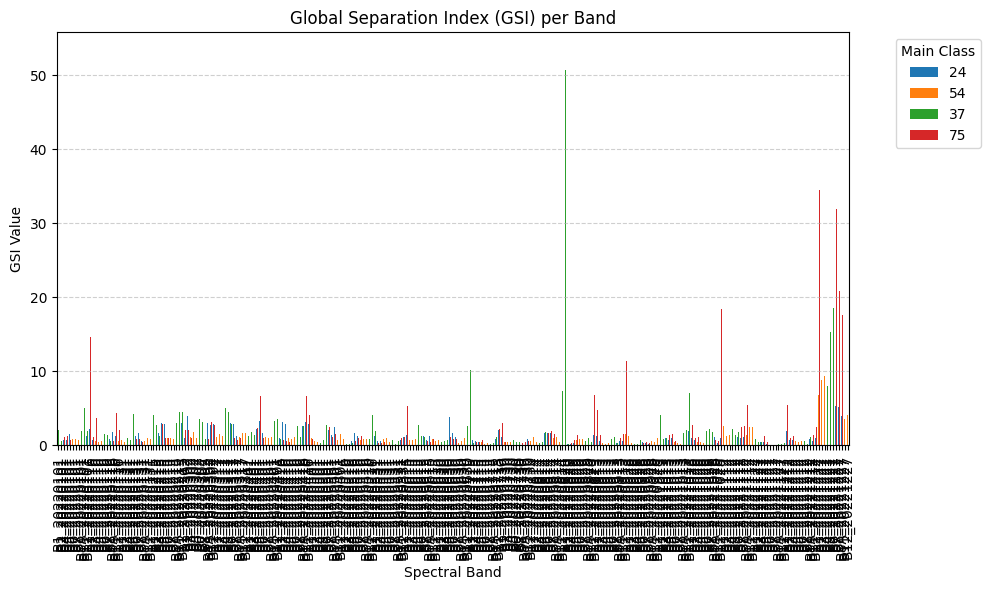

In [12]:
print("Computing GSI...")
gsi_df   = bs.calculate_gsi(df, CLASS_COL)
gsi_mean = gsi_df.mean(axis=1).sort_values(ascending=False)

print("\nGSI ranking (top 10):")
print(gsi_mean.head(10).to_string())
bs.plot_gsi(gsi_df, save_path="gsi_plot.png")

## 1.3 — Compute RF Feature Importance

Computing RF feature importance...

RF importance ranking (top 10):
B8_20220317    1.000000
B4_20220531    0.857469
B4_20220630    0.853649
B3_20220630    0.766615
B2_20220630    0.700158
B8_20220401    0.476681
B3_20220401    0.475684
B4_20220317    0.471879
B3_20220302    0.470807
B2_20220317    0.466914


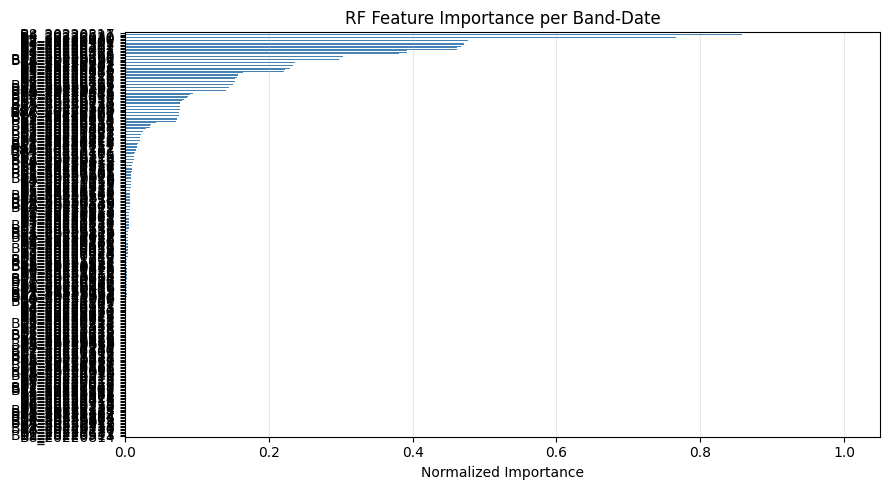

Saved: ../documents/thesis/figures/stage1_rf_importance.png


In [13]:
import matplotlib.pyplot as plt

print("Computing RF feature importance...")
rf_importance = bs.compute_rf_importance(df, CLASS_COL, n_estimators=200)

print("\nRF importance ranking (top 10):")
print(rf_importance.head(10).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
rf_importance.sort_values().plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("RF Feature Importance per Band-Date", fontsize=12)
ax.set_xlabel("Normalized Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
rf_path = os.path.join(FIGURES_DIR, "stage1_rf_importance.png")
plt.savefig(rf_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {rf_path}")

## 1.4 — Compute Joint Score & Select Top K

Stage 1 selected 25 bands (top-25):
  ['B8_20220317', 'B1_20220829', 'B4_20220630', 'B4_20220531', 'B3_20220630', 'B2_20220630', 'B1_20221227', 'B7_20221227', 'B4_20220317', 'B11_20221227', 'B4_20220302', 'B6_20221227', 'B2_20220317', 'B4_20220401', 'B2_20221227', 'B3_20220302', 'B3_20220401', 'B3_20221227', 'B2_20220401', 'B8_20220401', 'B5_20221227', 'B3_20220317', 'B3_20220416', 'B1_20220516', 'B8_20221227']

              GSI (norm)  RF (norm)  Joint Score  Selected
B8_20220317     0.031609   1.000000     0.515805      True
B1_20220829     1.000000   0.005815     0.502908      True
B4_20220630     0.035724   0.853649     0.444686      True
B4_20220531     0.019790   0.857469     0.438630      True
B3_20220630     0.038585   0.766615     0.402600      True
B2_20220630     0.035348   0.700158     0.367753      True
B1_20221227     0.648905   0.001741     0.325323      True
B7_20221227     0.603023   0.001294     0.302159      True
B4_20220317     0.129353   0.471879     0.300616     

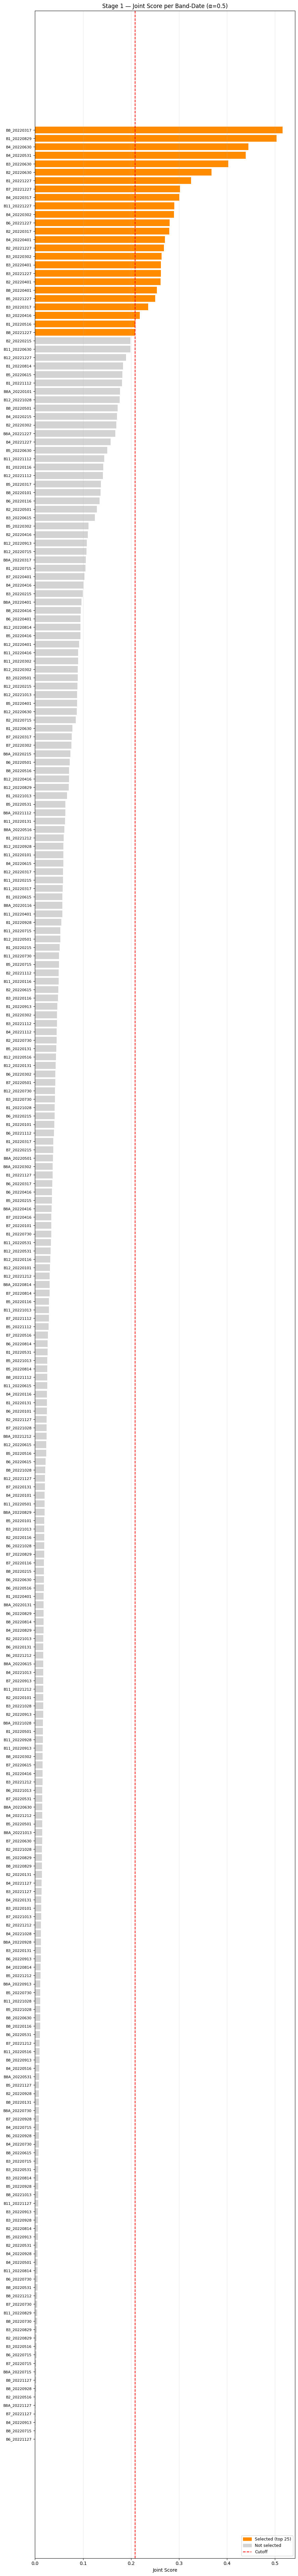

Saved: ../documents/thesis/figures/stage1_joint_score.png
🏃 View run stage1_gsi_rf_20260310-025412 at: https://mlflow-geoai.stelarea.com/#/experiments/26/runs/cab62a9ebf824986b11e51fab6fab4be
🧪 View experiment at: https://mlflow-geoai.stelarea.com/#/experiments/26

✅ Stage 1 logged to MLflow  (run_id: cab62a9ebf824986b11e51fab6fab4be)
   Selected bands: ['B8_20220317', 'B1_20220829', 'B4_20220630', 'B4_20220531', 'B3_20220630', 'B2_20220630', 'B1_20221227', 'B7_20221227', 'B4_20220317', 'B11_20221227', 'B4_20220302', 'B6_20221227', 'B2_20220317', 'B4_20220401', 'B2_20221227', 'B3_20220302', 'B3_20220401', 'B3_20221227', 'B2_20220401', 'B8_20220401', 'B5_20221227', 'B3_20220317', 'B3_20220416', 'B1_20220516', 'B8_20221227']


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import tempfile, pathlib

joint_score  = bs.compute_joint_score(gsi_mean, rf_importance, alpha=GSI_RF_ALPHA)
stage1_bands = bs.select_top_k(joint_score, k=TOP_K)

# Summary table
gsi_norm = (gsi_mean - gsi_mean.min()) / (gsi_mean.max() - gsi_mean.min() + 1e-9)
summary  = pd.DataFrame({
    "GSI (norm)":  gsi_norm,
    "RF (norm)":   rf_importance,
    "Joint Score": joint_score,
}).sort_values("Joint Score", ascending=False)
summary["Selected"] = summary.index.isin(stage1_bands)

print(f"Stage 1 selected {len(stage1_bands)} bands (top-{TOP_K}):\n  {stage1_bands}")
print()
print(summary.to_string())

# ── Plot: joint score bar chart with top-K cutoff highlighted ─────────────────
sorted_scores = summary["Joint Score"].sort_values()
colors = ["darkorange" if summary.loc[b, "Selected"] else "lightgray"
          for b in sorted_scores.index]

fig, ax = plt.subplots(figsize=(9, max(5, len(sorted_scores) * 0.28)))
bars = ax.barh(range(len(sorted_scores)), sorted_scores.values, color=colors)
ax.set_yticks(range(len(sorted_scores)))
ax.set_yticklabels(sorted_scores.index, fontsize=8)
ax.axvline(joint_score[stage1_bands[-1]], color="red", linestyle="--",
           label=f"Top-{TOP_K} cutoff")
ax.set_title(f"Stage 1 — Joint Score per Band-Date (α={GSI_RF_ALPHA})", fontsize=12)
ax.set_xlabel("Joint Score")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)

# Colour legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="darkorange", label=f"Selected (top {TOP_K})"),
    Patch(color="lightgray",  label="Not selected"),
    plt.Line2D([0], [0], color="red", linestyle="--", label="Cutoff"),
], fontsize=9, loc="lower right")

plt.tight_layout()
joint_path = os.path.join(FIGURES_DIR, "stage1_joint_score.png")
plt.savefig(joint_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {joint_path}")

# ── Log to MLflow (always close the run, even on error) ───────────────────────
try:
    for band in all_bandnames:
        mlflow.log_metric(f"gsi_{band}",   float(gsi_norm.get(band, 0)))
        mlflow.log_metric(f"rf_{band}",    float(rf_importance.get(band, 0)))
        mlflow.log_metric(f"joint_{band}", float(joint_score.get(band, 0)))

    mlflow.set_tag("stage1_selected_bands", str(stage1_bands))
    mlflow.set_tag("stage1_n_selected",     str(len(stage1_bands)))
    mlflow.set_tag("stage1_top_k",          str(TOP_K))

    # Use log_artifact via temp file — log_text bypasses the proxy and hits S3 directly
    with tempfile.TemporaryDirectory() as _tmp:
        _p = pathlib.Path(_tmp) / "stage1_band_scores.csv"
        _p.write_text(summary.to_csv())
        mlflow.log_artifact(str(_p))
    mlflow.log_artifact(os.path.join(FIGURES_DIR, "stage1_rf_importance.png"))
    mlflow.log_artifact(joint_path)

    mlflow.end_run(status="FINISHED")
    print(f"\n✅ Stage 1 logged to MLflow  (run_id: {stage1_run.info.run_id})")
except Exception as e:
    mlflow.end_run(status="FAILED")
    raise e

print(f"   Selected bands: {stage1_bands}")


---
# Stage 2 — CNN Forward Selection
**Goal:** Use a lightweight U-Net as the selection oracle. Iteratively add bands, keeping only those that raise validation mIoU by at least δ.

$$\text{keep band } b \iff \text{mIoU}_{\text{new}} > \text{mIoU}_{\text{prev}} + \delta$$

> ⚠️ Each iteration trains a small model for ~15 epochs. Expect ~6–10 hours total.

In [15]:
# ── Utility: close any stuck MLflow run ───────────────────────────────────────
# Run this cell if you see a run stuck as "RUNNING" in the MLflow UI.
import mlflow

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
active = mlflow.active_run()
if active:
    print(f"Closing stale run: {active.info.run_id}  ({active.info.run_name})")
    mlflow.end_run(status="FAILED")
    print("Done.")
else:
    print("No active run — nothing to close.")


No active run — nothing to close.


## 2.1 — Setup

In [16]:
import time
import numpy as np
import torch
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader, random_split

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")

# Map band name → index in the stacked n_channels array
band_index = {name: i for i, name in enumerate(all_bandnames)}
print(f"Band index map ({len(band_index)} entries): first 5 = {list(band_index.items())[:5]}")

# Lookup table for CDL ID → model sequential ID (0=background, 1-11=crops)
# Using LUT indexed by CDL ID for fast vectorized remapping
REMAP_LUT = np.zeros(256, dtype=np.int64)   # all → 0 (background)
for cdl_id, model_id in CLASS_REMAP.items():
    if cdl_id < 256:
        REMAP_LUT[cdl_id] = model_id

print(f"\nClass remap (CDL→model): {CLASS_REMAP}")
print(f"NUM_CLASSES: {NUM_CLASSES}")

/Users/dikaizm/Documents/PROGRAMMING/ml-ai/research-crop-mapping-thesis/research-crop-mapping-geoai/.venv/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/dikaizm/Documents/PROGRAMMING/ml-ai/research-crop-mapping-thesis/research-crop-mapping-geoai/.venv/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen'

Device: mps
Band index map (275 entries): first 5 = [('B1_20220101', 0), ('B2_20220101', 1), ('B3_20220101', 2), ('B4_20220101', 3), ('B5_20220101', 4)]

Class remap (CDL→model): {3: 1, 6: 2, 24: 3, 36: 4, 37: 5, 54: 6, 69: 7, 75: 8, 76: 9, 220: 10}
NUM_CLASSES: 11


In [17]:
from torch.utils.data import Dataset

class RasterPatchDataset(Dataset):
    """
    Generate image/mask patch pairs on-the-fly from processed rasters.

    Avoids pre-generating chip files; works directly with the S2 and CDL
    outputs of 02_image_processing.ipynb.

    - CDL is loaded into memory once to build the valid patch index cheaply.
    - S2 files are kept open and accessed via rasterio windows per-patch.
    - CDL class IDs are remapped to sequential model IDs via REMAP_LUT.
    """

    def __init__(self, s2_paths, cdl_path, patch_size, stride,
                 min_valid_frac=0.3, band_indices=None):
        self.s2_paths     = s2_paths
        self.cdl_path     = cdl_path
        self.patch_size   = patch_size
        self.band_indices = band_indices

        # Load CDL into memory to build the patch index (cheap: ~26 MB uint8)
        with rasterio.open(cdl_path) as src:
            self._cdl   = src.read(1).astype(np.int32)
            self.height = src.height
            self.width  = src.width

        # Open S2 rasterio sources once and reuse across all __getitem__ calls
        # (num_workers=0 required — rasterio handles cannot be pickled)
        self._s2_srcs = [rasterio.open(p) for p in s2_paths]

        # Build list of valid patch top-left corners (row, col)
        ps = patch_size
        self.patches = [
            (r, c)
            for r in range(0, self.height - ps + 1, stride)
            for c in range(0, self.width  - ps + 1, stride)
            if np.isin(self._cdl[r:r+ps, c:c+ps], KEEP_CLASSES).mean() >= min_valid_frac
        ]
        print(f"RasterPatchDataset: {len(self.patches)} valid patches  "
              f"(patch={ps}px, stride={stride}px, min_valid={min_valid_frac})")

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        r, c = self.patches[idx]
        ps   = self.patch_size
        win  = rasterio.windows.Window(c, r, ps, ps)

        # Read all temporal S2 files and stack along the channel axis
        arrays = [src.read(window=win).astype(np.float32) for src in self._s2_srcs]
        img    = np.concatenate(arrays, axis=0)   # (n_channels, ps, ps)

        # Select band subset if specified
        if self.band_indices is not None:
            img = img[self.band_indices]

        # Replace nodata sentinel with 0 before normalization
        img[img == S2_NODATA] = 0.0

        # Per-channel min-max normalization
        for ch in range(img.shape[0]):
            mn, mx = img[ch].min(), img[ch].max()
            img[ch] = (img[ch] - mn) / (mx - mn + 1e-9)

        # Remap CDL IDs → sequential model class IDs (0-11)
        cdl_patch = self._cdl[r:r+ps, c:c+ps]
        mask      = REMAP_LUT[np.clip(cdl_patch, 0, 255)]

        return torch.from_numpy(img), torch.from_numpy(mask.astype(np.int64))

    def __del__(self):
        for src in getattr(self, "_s2_srcs", []):
            try:
                src.close()
            except Exception:
                pass


In [18]:
def build_unet(in_channels, num_classes, encoder=S2_ENCODER):
    return smp.Unet(
        encoder_name=encoder,
        encoder_weights=None,   # no pretrained weights — channel count varies
        in_channels=in_channels,
        classes=num_classes,
    ).to(DEVICE)


def compute_miou(preds, labels, num_classes, ignore_index=0):
    """Mean IoU over foreground classes (class 0 = background, skipped)."""
    preds_np  = preds.view(-1).cpu().numpy()
    labels_np = labels.view(-1).cpu().numpy()
    ious = []
    for cls in range(1, num_classes):
        p = preds_np  == cls
        l = labels_np == cls
        intersection = (p & l).sum()
        union        = (p | l).sum()
        if union > 0:
            ious.append(intersection / union)
    return float(np.mean(ious)) if ious else 0.0


def train_eval(band_indices, num_classes, epochs=S2_EPOCHS, patience=S2_PATIENCE):
    """
    Train a lightweight U-Net on the given band subset.
    Uses RasterPatchDataset to generate patches on-the-fly from processed rasters.
    Returns best validation mIoU.
    """
    dataset = RasterPatchDataset(
        s2_paths=S2_PROCESSED,
        cdl_path=CDL_FILTERED,
        patch_size=S2_PATCH_SIZE,
        stride=S2_STRIDE,
        min_valid_frac=S2_MIN_VALID,
        band_indices=band_indices,
    )

    if len(dataset) < 4:
        print(f"  ⚠️  Only {len(dataset)} patches — skipping.")
        return 0.0

    n_val   = max(1, int(0.2 * len(dataset)))
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(
        dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(42),
    )

    # num_workers=0: rasterio file handles cannot be pickled for forked workers
    train_dl = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0)

    model     = build_unet(len(band_indices), num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss(ignore_index=0)

    best_miou, no_improve = 0.0, 0

    for epoch in range(epochs):
        model.train()
        for imgs, masks in train_dl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(imgs), masks).backward()
            optimizer.step()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, masks in val_dl:
                preds = model(imgs.to(DEVICE)).argmax(dim=1)
                all_preds.append(preds.cpu())
                all_labels.append(masks)

        miou = compute_miou(
            torch.cat(all_preds), torch.cat(all_labels), num_classes
        )

        if miou > best_miou + 1e-4:
            best_miou, no_improve = miou, 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return best_miou


## 2.2 — Forward Selection Loop

In [19]:
import tempfile, pathlib

candidates = stage1_bands   # ordered by joint score (descending from Stage 1)
selected   = []
prev_miou  = 0.0
no_improve = 0
history    = []

print(f"Forward selection — {len(candidates)} candidates  "
      f"(δ={S2_DELTA}, patience={S2_NO_IMPROVE}, max_bands={S2_MAX_BANDS})\n")

# ── Start Stage 2 MLflow run ──────────────────────────────────────────────────
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

# Close any stale active run (e.g. Stage 1 run not yet closed, or interrupted cell)
if mlflow.active_run():
    print(f"[cleanup] Closing stale run: {mlflow.active_run().info.run_id}")
    mlflow.end_run(status="FAILED")

# stage1_run may not exist if Stage 2 is re-run after a kernel restart
_stage1_run_id = stage1_run.info.run_id if "stage1_run" in vars() else ""

stage2_run = mlflow.start_run(run_name=f"stage2_cnn_fwd_{RUN_TIMESTAMP}")

# Confirm artifact URI for this run
_stage2_artifact_uri = mlflow.get_artifact_uri()
_stage2_has_proxy = _stage2_artifact_uri.startswith("mlflow-artifacts:")
print(f"Run artifact URI : {_stage2_artifact_uri}")

mlflow.log_params({
    "stage":         "2_cnn_forward_selection",
    "encoder":       S2_ENCODER,
    "patch_size":    S2_PATCH_SIZE,
    "stride":        S2_STRIDE,
    "min_valid":     S2_MIN_VALID,
    "epochs":        S2_EPOCHS,
    "patience":      S2_PATIENCE,
    "delta":         S2_DELTA,
    "no_improve":    S2_NO_IMPROVE,
    "max_bands":     S2_MAX_BANDS,
    "candidates":    str(candidates),
    "num_classes":   NUM_CLASSES,
    "stage1_run_id": _stage1_run_id,
})

print(f"Stage 2 run ID: {stage2_run.info.run_id}")

# ── Forward selection loop ────────────────────────────────────────────────────
try:
    for step, band in enumerate(candidates):
        if len(selected) >= S2_MAX_BANDS:
            print(f"Reached max_bands={S2_MAX_BANDS}. Stopping.")
            break
        if no_improve >= S2_NO_IMPROVE:
            print(f"No improvement for {S2_NO_IMPROVE} consecutive bands. Stopping.")
            break

        trial_bands   = selected + [band]
        trial_indices = [band_index[b] for b in trial_bands]

        t0      = time.time()
        miou    = train_eval(trial_indices, NUM_CLASSES)
        elapsed = time.time() - t0

        gain     = miou - prev_miou
        accepted = gain >= S2_DELTA

        if accepted:
            selected   = trial_bands
            prev_miou  = miou
            no_improve = 0
            tag = "✅ accepted"
        else:
            no_improve += 1
            tag = "❌ rejected"

        history.append({
            "step": step, "band": band, "n_bands": len(selected),
            "mIoU": round(miou, 4), "gain": round(gain, 4),
            "accepted": accepted, "elapsed_s": round(elapsed),
        })

        # Log per-step metrics
        mlflow.log_metrics({"miou": miou, "gain": gain, "accepted": int(accepted)},
                            step=step)

        print(f"  {tag}  +{band:<22}  mIoU={miou:.4f}  gain={gain:+.4f}  ({elapsed:.0f}s)")

    stage2_bands = selected

    # ── Log final results ──────────────────────────────────────────────────────
    mlflow.set_tag("stage2_selected_bands", str(stage2_bands))
    mlflow.set_tag("stage2_n_selected",     str(len(stage2_bands)))
    mlflow.log_metric("final_miou", prev_miou)
    mlflow.log_metric("n_selected", len(stage2_bands))

    hist_df = pd.DataFrame(history)

    # Use log_artifact via temp file — log_text bypasses the proxy and hits S3 directly
    with tempfile.TemporaryDirectory() as _tmp:
        _p = pathlib.Path(_tmp) / "stage2_forward_selection_history.csv"
        _p.write_text(hist_df.to_csv(index=False))
        mlflow.log_artifact(str(_p))

    mlflow.end_run(status="FINISHED")
    print(f"\n✅ Stage 2 complete — {len(stage2_bands)} bands: {stage2_bands}")
    print(f"   Final mIoU    : {prev_miou:.4f}")
    print(f"   MLflow run ID : {stage2_run.info.run_id}")
    print(f"\n{hist_df.to_string(index=False)}")

except Exception as e:
    mlflow.end_run(status="FAILED")
    raise e


Forward selection — 25 candidates  (δ=0.005, patience=3, max_bands=15)

Run artifact URI : mlflow-artifacts:/26/0c38f0cf50dd42f8bf6ced7f43b5bfcf/artifacts
Stage 2 run ID: 0c38f0cf50dd42f8bf6ced7f43b5bfcf
RasterPatchDataset: 1075 valid patches  (patch=128px, stride=128px, min_valid=0.3)
  ✅ accepted  +B8_20220317             mIoU=0.1061  gain=+0.1061  (1368s)
RasterPatchDataset: 1075 valid patches  (patch=128px, stride=128px, min_valid=0.3)
  ✅ accepted  +B1_20220829             mIoU=0.1207  gain=+0.0146  (1623s)
RasterPatchDataset: 1075 valid patches  (patch=128px, stride=128px, min_valid=0.3)
  ✅ accepted  +B4_20220630             mIoU=0.1365  gain=+0.0158  (1668s)
RasterPatchDataset: 1075 valid patches  (patch=128px, stride=128px, min_valid=0.3)
  ✅ accepted  +B4_20220531             mIoU=0.1719  gain=+0.0353  (1646s)
RasterPatchDataset: 1075 valid patches  (patch=128px, stride=128px, min_valid=0.3)
  ❌ rejected  +B3_20220630             mIoU=0.1752  gain=+0.0033  (1637s)
RasterPatch

## 2.3 — Plot mIoU vs Band Count

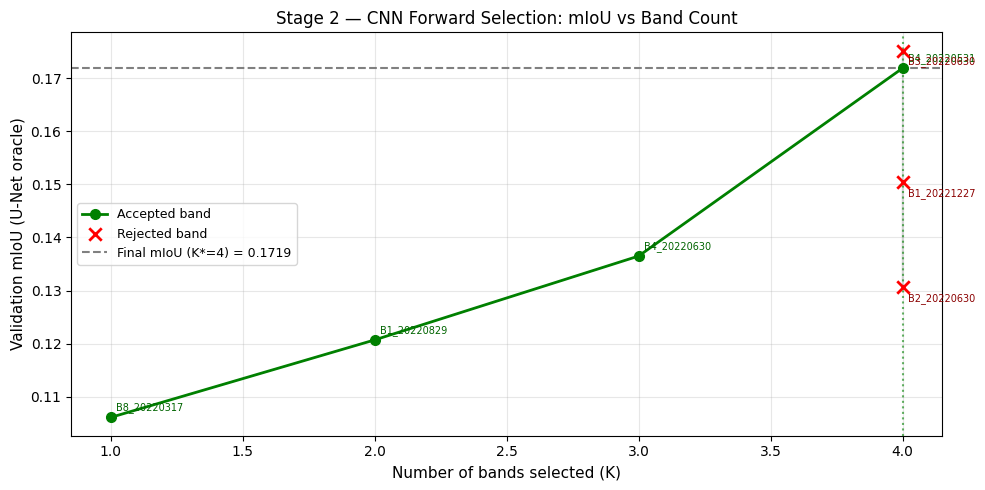

Saved: ../documents/thesis/figures/stage2_forward_selection.png

=== Forward Selection History ===
 step        band  n_bands   mIoU    gain  accepted  elapsed_s
    0 B8_20220317        1 0.1061  0.1061      True       1368
    1 B1_20220829        2 0.1207  0.0146      True       1623
    2 B4_20220630        3 0.1365  0.0158      True       1668
    3 B4_20220531        4 0.1719  0.0353      True       1646
    4 B3_20220630        4 0.1752  0.0033     False       1637
    5 B2_20220630        4 0.1307 -0.0411     False       1302
    6 B1_20221227        4 0.1504 -0.0215     False       1650

K* = 4 bands: ['B8_20220317', 'B1_20220829', 'B4_20220630', 'B4_20220531']
Saved: /Volumes/T7/research-crop-mapping-geoai/data/processed/stage2_history.csv


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)

accepted_df = hist_df[hist_df["accepted"]]
rejected_df = hist_df[~hist_df["accepted"]]

fig, ax = plt.subplots(figsize=(10, 5))

# Draw grey line through all evaluated steps
ax.plot(hist_df["n_bands"], hist_df["mIoU"], color="lightgray", linewidth=1, zorder=1)

# Accepted points with band labels
ax.plot(accepted_df["n_bands"], accepted_df["mIoU"],
        "o-", color="green", linewidth=2, markersize=7, label="Accepted band", zorder=3)
for _, row in accepted_df.iterrows():
    ax.annotate(row["band"], (row["n_bands"], row["mIoU"]),
                textcoords="offset points", xytext=(4, 5), fontsize=7, color="darkgreen")

# Rejected points
ax.scatter(rejected_df["n_bands"], rejected_df["mIoU"],
           marker="x", color="red", s=80, linewidths=2, label="Rejected band", zorder=3)
for _, row in rejected_df.iterrows():
    ax.annotate(row["band"], (row["n_bands"], row["mIoU"]),
                textcoords="offset points", xytext=(4, -10), fontsize=7, color="darkred")

# Final K* line
ax.axhline(prev_miou, linestyle="--", color="gray",
           label=f"Final mIoU (K*={len(selected)}) = {prev_miou:.4f}")
ax.axvline(len(selected), linestyle=":", color="green", alpha=0.6)

ax.set_xlabel("Number of bands selected (K)", fontsize=11)
ax.set_ylabel("Validation mIoU (U-Net oracle)", fontsize=11)
ax.set_title("Stage 2 — CNN Forward Selection: mIoU vs Band Count", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

sel_path = os.path.join(FIGURES_DIR, "stage2_forward_selection.png")
plt.savefig(sel_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {sel_path}")

print("\n=== Forward Selection History ===")
print(hist_df.to_string(index=False))
print(f"\nK* = {len(selected)} bands: {selected}")

# Save selection history
stage2_bands = selected
hist_df.to_csv(os.path.join(PROCESSED_DIR, "stage2_history.csv"), index=False)
print(f"Saved: {os.path.join(PROCESSED_DIR, 'stage2_history.csv')}")

---
# Stage 3 — Full Model Validation
**Goal:** Train full segmentation models on three band sets and compare performance.

| Experiment | Band Set | Description |
|---|---|---|
| A — Baseline | All bands | No selection |
| B — Stage 1 | Top-K filter bands | GSI + RF only |
| C — Stage 2 | CNN-selected bands | Forward selection |

Each trained with: U-Net · DeepLabV3+ · SegFormer

## 3.1 — Define Experiments

In [21]:
print("⚠️  Stage 3 (Full Model Validation) is skipped in the small-scale test run.")
print("   It requires chip generation via 02_image_processing and ~27 GPU-hours.")
print(f"   Stage 2 selected bands: {stage2_bands}")
print("   Run Stage 3 separately on GPU server with full dataset.")

⚠️  Stage 3 (Full Model Validation) is skipped in the small-scale test run.
   It requires chip generation via 02_image_processing and ~27 GPU-hours.
   Stage 2 selected bands: ['B8_20220317', 'B1_20220829', 'B4_20220630', 'B4_20220531']
   Run Stage 3 separately on GPU server with full dataset.


## 3.2 — Train & Evaluate

> ⚠️ This will take ~27 GPU hours (3 models × 3 experiments × ~3 hours each). Run on a GPU server.

In [22]:
# Stage 3 training — skipped for small-scale test (see note above)
# Uncomment and run on GPU server with full dataset
raise SystemExit("Stage 3 skipped — run on GPU server")

SystemExit: Stage 3 skipped — run on GPU server

/Users/dikaizm/Documents/PROGRAMMING/ml-ai/research-crop-mapping-thesis/research-crop-mapping-geoai/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## 3.3 — Compare Results

In [ ]:
# results_df = pd.DataFrame(results)
# results_df.to_csv("stage3_results.csv", index=False)

# # Pivot table: models as columns, experiments as rows
# pivot = results_df.pivot_table(
#     index=["experiment", "band_label"],
#     columns="model",
#     values="val_mIoU"
# ).round(4)

# print("\nmIoU Comparison Table")
# print(pivot.to_string())

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # mIoU comparison
# for model_name, grp in results_df.groupby("model"):
#     axes[0].plot(grp["experiment"], grp["val_mIoU"], marker="o", label=model_name)
# axes[0].set_title("Validation mIoU by Experiment & Model")
# axes[0].set_ylabel("mIoU")
# axes[0].set_xlabel("Experiment")
# axes[0].legend()
# axes[0].grid(True)

# # Training time comparison
# for model_name, grp in results_df.groupby("model"):
#     axes[1].plot(grp["experiment"], grp["train_time_s"] / 3600, marker="s", label=model_name)
# axes[1].set_title("Training Time (hours) by Experiment & Model")
# axes[1].set_ylabel("Hours")
# axes[1].set_xlabel("Experiment")
# axes[1].legend()
# axes[1].grid(True)

# plt.tight_layout()
# plt.savefig("stage3_comparison.png", dpi=150)
# plt.show()